In [7]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2022.csv')

To see if our hierarchical structure actually improves our predictions, let's fit a simple, 'naive' model. This baseline model completely ignores regional differences (counties) and assumes all trees follow one universal growth trend


In [2]:
model_formula = "log_height ~ log_diameter"

model = bmb.Model(model_formula, df)

In [3]:
results = model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [4]:
az.summary(results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.222,0.009,0.206,0.238,0.000,0.000,6305.0,3184.0,1.0
Intercept,0.176,0.048,0.089,0.268,0.001,0.001,5739.0,3132.0,1.0
log_diameter,0.800,0.017,0.770,0.833,0.000,0.000,5674.0,2925.0,1.0


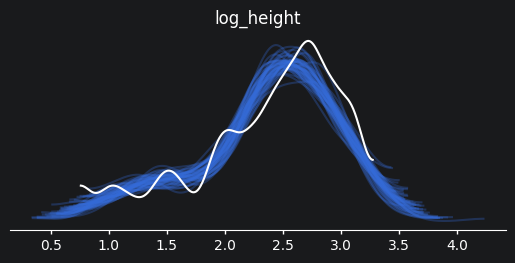

In [6]:
model.predict(results, kind="response")
azp.plot_ppc_dist(results)